
# # Dự đoán giá xe ô tô
# **Goal:** Xây dựng dự án dự đoán giá xe ô tô dùng mô hình:
# - Linear Models
# - XGBoost
# - Ensemble (Stacking)



# **#  ##1. Import libraries**

In [3]:
# %% import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import StackingRegressor,RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import joblib

#####
# Cài đặt phụ thuộc khi chạy trên Colab / môi trường mới
#!pip install -q numpy pandas matplotlib seaborn scikit-learn requests beautifulsoup4 openpyxl




# **## 2. Load Data**



In [4]:
#Đọc data từ git
url ="https://raw.githubusercontent.com/hoangchaulanbao/Vehicle/refs/heads/main/CAR.csv"
df = pd.read_csv(url)
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


Kích thước data

In [5]:
df.shape

(4340, 8)

# TIỀN XỬ LÝ DỮ LIỆU

# 1.KIỂM TRA MISSING DATA
Mục tiêu: Xem dữ liệu có thiếu không

In [6]:
print(df.isnull().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [7]:
# Print để nhìn rõ
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (4340, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB

Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


# 2. PHÂN TÍCH DỮ LIỆU (EDA)

Basic info

In [29]:
# Basic info
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
 8   car_age        4340 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 305.3+ KB
None
              year  selling_price      km_driven      car_age
count  4340.000000   4.340000e+03    4340.000000  4340.000000
mean   2013.090783   5.041273e+05   66215.777419    12.909217
std       4.215344   5.785487e+05   46644.102194     4.215344
min    1992.000000   2.000000e+04       1.000000     6.000000
25%    2011.000000   2.087498e+05   35000.000000    10


# Distribution of Price



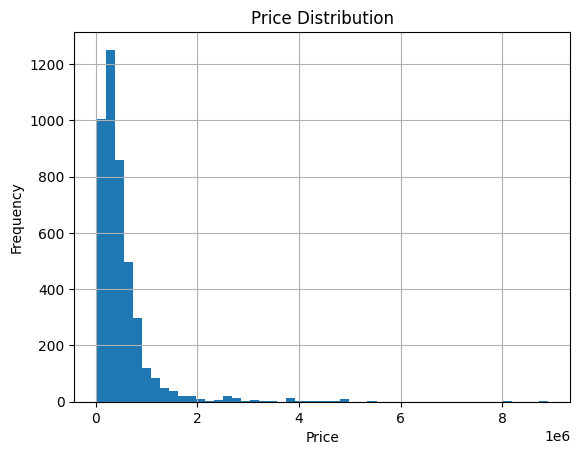

In [30]:
import matplotlib.pyplot as plt


plt.figure()
df['selling_price'].hist(bins=50)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# 3.Numeric Features Distribution

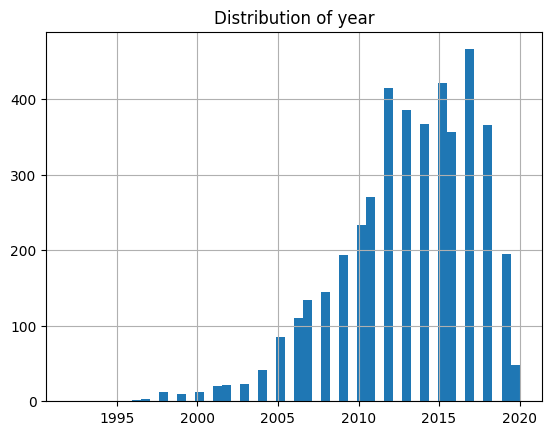

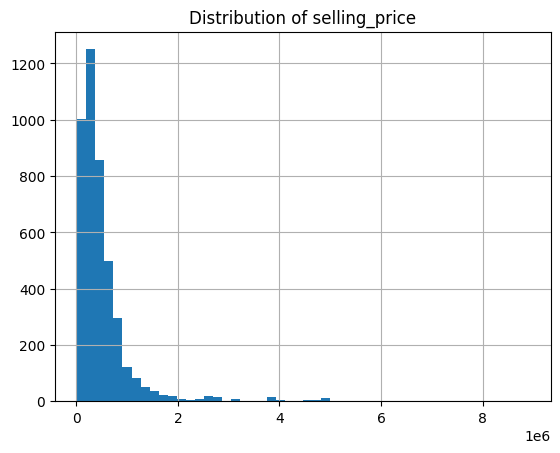

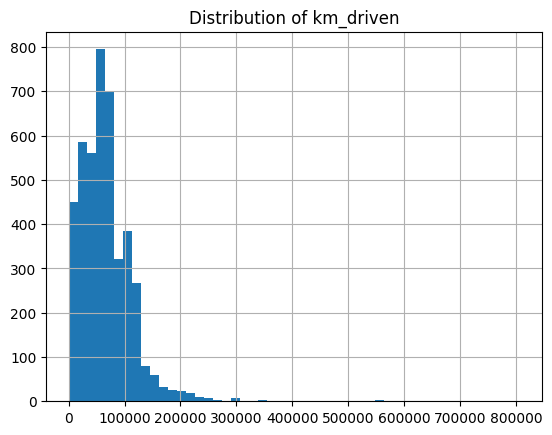

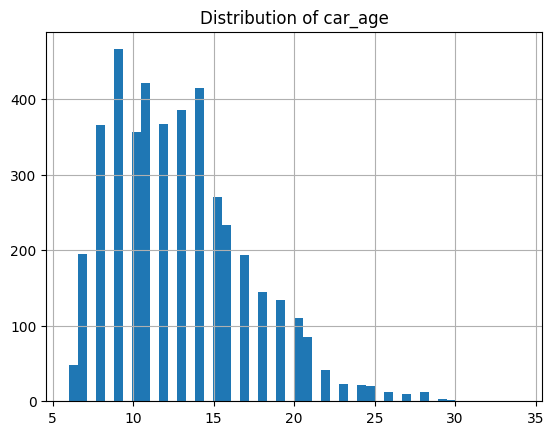

In [27]:
num_cols_all = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols_all:
    if col != 'price':
        plt.figure()
        df[col].hist(bins=50)
        plt.title(f'Distribution of {col}')
        plt.show()

# 4.Correlation Matrix

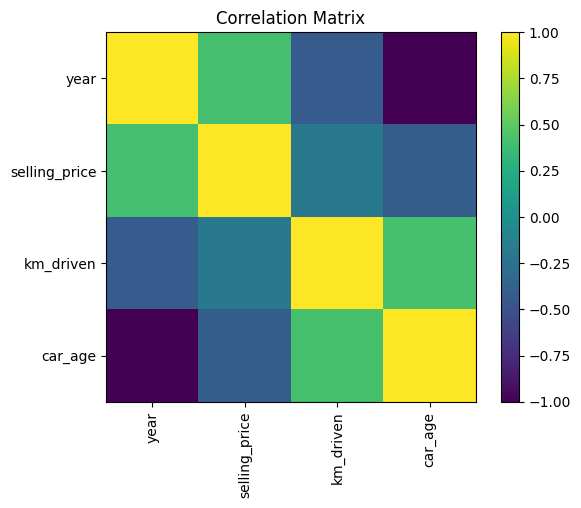

In [28]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

# Log Transform Visualization
Compare original price vs log(price)

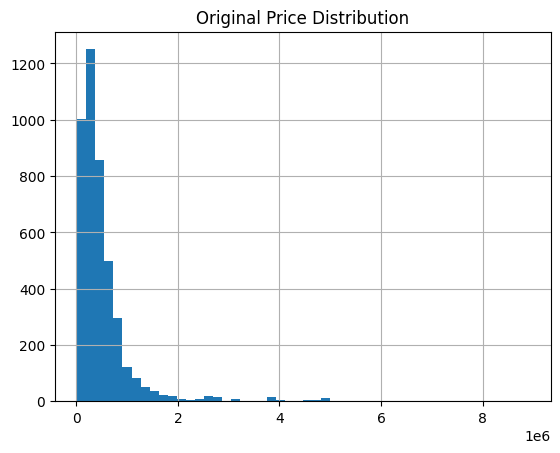

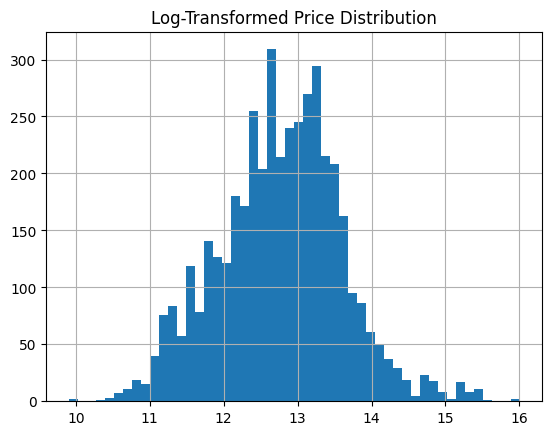

In [32]:
plt.figure()
df['selling_price'].hist(bins=50)
plt.title('Original Price Distribution')
plt.show()

plt.figure()
np.log1p(df['selling_price']).hist(bins=50)
plt.title('Log-Transformed Price Distribution')
plt.show()

# Observation:
 - Log transform helps reduce skewness
 - Makes model learn better (especially linear models)


# ## 3. Feature Engineering


In [33]:
def feature_engineering(df):
    df = df.copy()

    if 'year' in df.columns:
        df['car_age'] = 2026 - df['year']

    if 'price' in df.columns:
        df['log_price'] = np.log1p(df['price'])

    return df


df = feature_engineering(df)


# ## 4. Split Data



In [34]:

target = 'selling_price'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



# ## 5. Preprocessing Pipeline




In [35]:


num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


# ## 6. Define Models



In [15]:
# %% [markdown]
# ## 6. Define Models

# %%
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}


# ## 7. Train Models


In [16]:
# %% [markdown]
# ## 7. Train Models

# %%
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9949677228662.258, tolerance: 118722633817.65521
  model = cd_fast.sparse_enet_coordinate_descent(



# ## 8. Ensemble Model (Stacking)


In [17]:

# %% [markdown]
# ## 8. Ensemble Model (Stacking)

# %%
stack_model = StackingRegressor(
    estimators=[
        ('lr', LinearRegression()),
        ('ridge', Ridge()),
        ('lasso', Lasso()),
        ('xgb', XGBRegressor(n_estimators=200, random_state=42))
    ],
    final_estimator=LinearRegression()
)

stack_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', stack_model)
])

stack_pipeline.fit(X_train, y_train)
trained_models['Stacking'] = stack_pipeline

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1792834665717.5215, tolerance: 118722633817.65521
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1928579174000.998, tolerance: 95013488134.39359
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1399176986655.6934, tolerance: 97839292871.66475
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: Conve


# ## 9. Evaluation Function



In [18]:
# %% [markdown]
# ## 9. Evaluation Function

# %%
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }



# ## 10. Evaluate Models


In [19]:
# %% [markdown]
# ## 10. Evaluate Models

# %%
results = {}

for name, model in trained_models.items():
    pred = model.predict(X_test)
    results[name] = evaluate(y_test, pred)

results_df = pd.DataFrame(results).T
print(results_df)

                            MAE           RMSE        R2
LinearRegression  120932.272082  340864.915717  0.619265
Ridge             136112.214132  345379.280354  0.609114
Lasso             117965.555294  377671.816342  0.532602
XGBoost           152662.906250  364238.973511  0.565259
Stacking          116491.703967  335515.556343  0.631122



# 11. Cross Validation


In [20]:

for name, model in trained_models.items():
    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    print(f"{name} CV RMSE:", -scores.mean())

LinearRegression CV RMSE: 266904.38901728165
Ridge CV RMSE: 283107.6248751728


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8740833996049.893, tolerance: 105971050765.35927
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9792153463664.268, tolerance: 112172881076.03929
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 10865351917629.988, tolerance: 117592764534.4416
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: Conve

Lasso CV RMSE: 293368.19679304713
XGBoost CV RMSE: 289645.959375


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2060073838350.3203, tolerance: 105971050765.35927
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1576141004908.627, tolerance: 76305585318.46257
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2163164683679.8994, tolerance: 86037164537.47226
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: Conve

Stacking CV RMSE: 252881.2696208877


# SHAP Explainability (XGBoost)

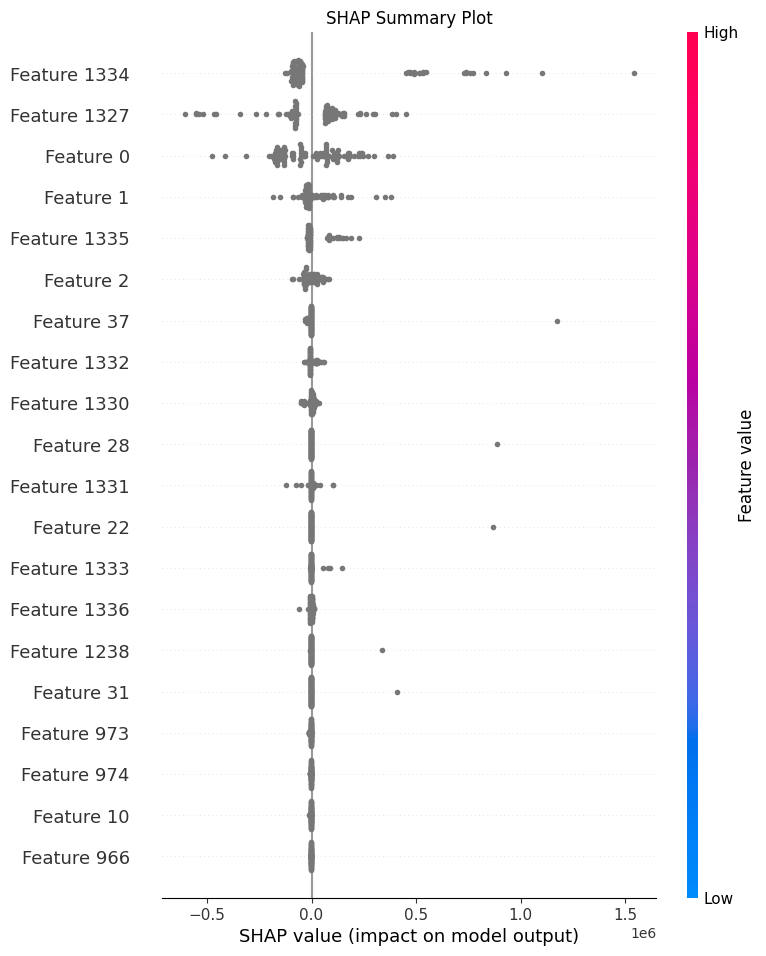

In [37]:
import shap

# Use a small sample for speed
sample_X = X_test.sample(100, random_state=42)

# Transform data using pipeline
X_transformed = trained_models['XGBoost'].named_steps['preprocess'].transform(sample_X)

# Extract the XGBoost model from the pipeline
xgb_model = trained_models['XGBoost'].named_steps['model']

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_transformed)

# Summary plot
shap.summary_plot(shap_values, X_transformed, show=False)
plt.title('SHAP Summary Plot')
plt.show()

# Feature Importance (XGBoost)


# 12. Save Best Model


In [21]:
best_model_name = results_df['RMSE'].idxmin()
best_model = trained_models[best_model_name]

import joblib
joblib.dump(best_model, 'best_model.pkl')

print(f"Best model: {best_model_name}")

Best model: Stacking



# ✅ Conclusion

# - XGBoost usually performs best for tabular data
# - Stacking provides stability
# - Linear models serve as baseline
